# E-Commerce Customer Analytics & RFM Segmentation

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load files
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

# Merge tables
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(items, on="order_id", how="left")
df = df.merge(payments, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")

print(df.shape)
df.head()


(118434, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


## Data Cleaning

In [2]:

df.isnull().sum().sort_values(ascending=False)
df.drop_duplicates(inplace=True)

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 118434 entries, 0 to 118433
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118434 non-null  object        
 1   customer_id                    118434 non-null  object        
 2   order_status                   118434 non-null  object        
 3   order_purchase_timestamp       118434 non-null  datetime64[ns]
 4   order_approved_at              118258 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116360 non-null  datetime64[ns]
 6   order_delivered_customer_date  115037 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118434 non-null  datetime64[ns]
 8   customer_unique_id             118434 non-null  object        
 9   customer_zip_code_prefix       118434 non-null  int64         
 10  customer_city                  118434 non-null  object        
 11  

## KPI Dashboard

In [3]:

total_revenue = df["payment_value"].sum()
total_customers = df["customer_unique_id"].nunique()
total_orders = df["order_id"].nunique()
aov = total_revenue / total_orders

print("Total Revenue:", round(total_revenue,2))
print("Total Customers:", total_customers)
print("Total Orders:", total_orders)
print("Average Order Value:", round(aov,2))


Total Revenue: 20470726.66
Total Customers: 96096
Total Orders: 99441
Average Order Value: 205.86


## Monthly Revenue Analysis

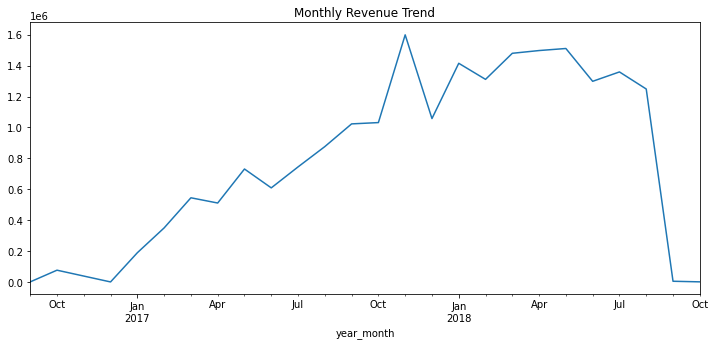

In [17]:

df["year_month"] = df["order_purchase_timestamp"].dt.to_period("M")

monthly_revenue = (
    df.groupby("year_month")["payment_value"]
    .sum()
)

plt.figure(figsize=(12,5))

monthly_revenue.plot()
plt.savefig("images/monthly_revenue.png")
plt.title("Monthly Revenue Trend")

plt.show()


## Top Customers

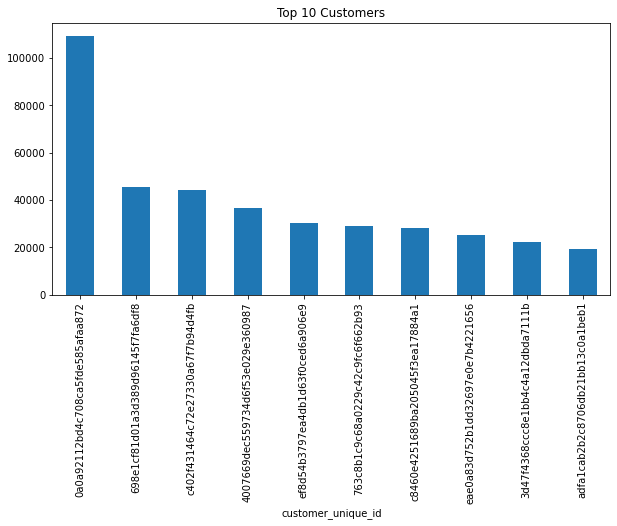

In [18]:

top_customers = (
    df.groupby("customer_unique_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers")
plt.savefig("images/top_customers.png")
plt.show()


## Repeat Customer Analysis

In [7]:

customer_orders = df.groupby("customer_unique_id")["order_id"].nunique()
repeat_customers = (customer_orders > 1).sum()
print("Repeat Customers:", repeat_customers)


Repeat Customers: 2997


## Top Product Categories

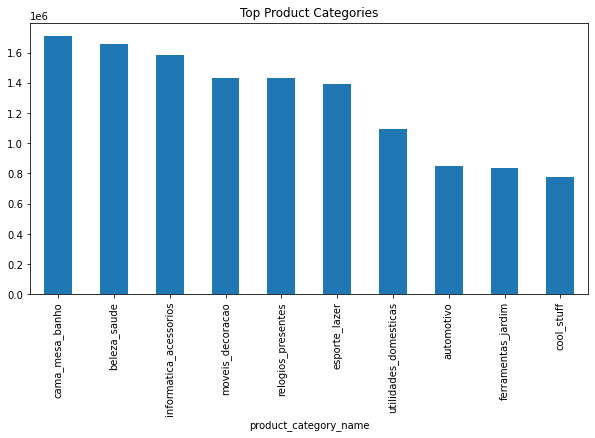

In [19]:

top_categories = (
    df.groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar")
plt.title("Top Product Categories")
plt.savefig("images/top_categories.png")
plt.show()


## Payment Method Analysis

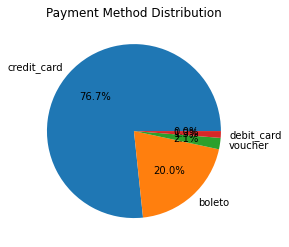

In [20]:

payment_method = (
    df.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_method.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Payment Method Distribution")
plt.savefig("images/payment_method.png")
plt.show()


## State-wise Revenue

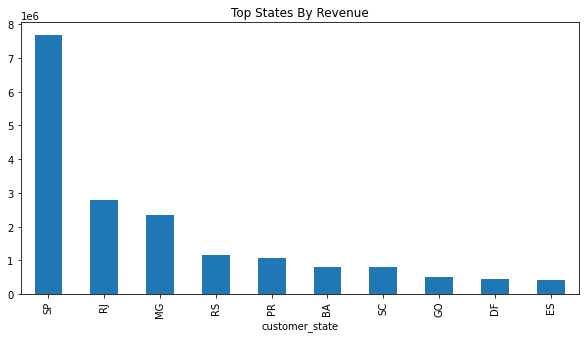

In [21]:

state_revenue = (
    df.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
state_revenue.plot(kind="bar")
plt.title("Top States By Revenue")
plt.savefig("images/state_revenue.png")
plt.show()


## RFM Segmentation

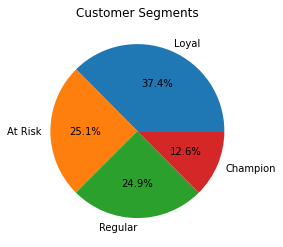

In [22]:

snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("customer_unique_id")
    .agg({
        "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
        "order_id":"nunique",
        "payment_value":"sum"
    })
)

rfm.columns = ["Recency","Frequency","Monetary"]

rfm["R"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm["Score"] = (
    rfm["R"].astype(str)
    + rfm["F"].astype(str)
    + rfm["M"].astype(str)
)

def segment(row):
    if row["R"] == 4 and row["F"] >= 3:
        return "Champion"
    elif row["F"] >= 3:
        return "Loyal"
    elif row["R"] <= 2:
        return "At Risk"
    else:
        return "Regular"

rfm["Customer_Type"] = rfm.apply(segment, axis=1)

rfm["Customer_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Customer Segments")
plt.savefig("images/rfm.png")
plt.show()


## SQLAlchemy

In [13]:

from sqlalchemy import create_engine

engine = create_engine("sqlite:///ecommerce.db")
df["year_month"] = df["year_month"].astype(str)
df.to_sql(
    "sales",
    engine,
    if_exists="replace",
    index=False
)

pd.read_sql(
    """
    SELECT customer_state,
           SUM(payment_value) revenue
    FROM sales
    GROUP BY customer_state
    ORDER BY revenue DESC
    LIMIT 10
    """,
    engine
)


,customer_state,revenue
0,SP,7673188.55
1,RJ,2783724.26
2,MG,2341861.47
3,RS,1152019.17
4,PR,1074614.19
5,BA,802416.72
6,SC,799135.92
7,GO,516182.51
8,DF,434512.55
9,ES,406946.26


## OpenPyXL Export

In [14]:

from openpyxl import Workbook

wb = Workbook()
ws = wb.active
ws.title = "Customer Segments"

for row in rfm.reset_index().values.tolist():
    ws.append(row)

wb.save("customer_segments.xlsx")
print("Excel report saved.")


Excel report saved.
